In [1]:
import warnings
warnings.filterwarnings('ignore')

About this notebook

Author: Anubhav Jain
Github repo: https://github.com/computron/pymatgen_tutorials
YouTube video: https://youtu.be/b0tieiedGdg

![Learn Atomate 2 Part 1](graphics/title.png)

![Atomate 2 Overview](graphics/overview.png)

# Atomate2 features

Atomate2 allows users to to quickly and easily run many different types of materials calculations. A list of available workflows at the time of this tutorial is shown in the table below.
- circles indicate on near-term development roadmap
- triangles indicate relatively simple to implement (but not planned)


![Feature matrix](graphics/feature_matrix.png)
```
Ganose, A. M. et al. Atomate2: Modular Workflows for Materials Science. Digital Discovery 2025. https://doi.org/10.1039/d5dd00019j.
```

# What this tutorial covers

By the end of this tutorial, you will have:

* installed atomate2 locally on your computer
* run thermal and mechanical property simulations using machine-learned potentials

![Part 1](graphics/part1.png)


Later tutorials will cover:
* Running more complex DFT workflows
* Upgrading to MongoDB for more powerful data management and parallel execution
* Running atomate2 on high performance computing clusters with batch job submission
* Tips, tricks, and internals of atomate2

Finally, if you use atomate2, please be sure to cite the paper:
```
Ganose, A. M.; Sahasrabuddhe, H.; Asta, M.; Beck, K.; Biswas, T.; Bonkowski, A.; Bustamante, J.; Chen, X.; Chiang, Y.; Chrzan, D. C.; Clary, J.; Cohen, O. A.; Ertural, C.; Gallant, M. C.; George, J.; Gerits, S.; Goodall, R. E. A.; Guha, R. D.; Hautier, G.; Horton, M.; Inizan, T. J.; Kaplan, A. D.; Kingsbury, R. S.; Kuner, M. C.; Li, B.; Linn, X.; McDermott, M. J.; Mohanakrishnan, R. S.; Naik, A. N.; Neaton, J. B.; Parmar, S. M.; Persson, K. A.; Petretto, G.; Purcell, T. A. R.; Ricci, F.; Rich, B.; Riebesell, J.; Rignanese, G.-M.; Rosen, A. S.; Scheffler, M.; Schmidt, J.; Shen, J.-X.; Sobolev, A.; Sundararaman, R.; Tezak, C.; Trinquet, V.; Varley, J. B.; Vigil-Fowler, D.; Wang, D.; Waroquiers, D.; Wen, M.; Yang, H.; Zheng, H.; Zheng, J.; Zhu, Z.; Jain, A. Atomate2: Modular Workflows for Materials Science. Digital Discovery 2025. https://doi.org/10.1039/d5dd00019j.
```

#  1. Installing and configuring atomate2

The most basic installation of atomate2 involves installing the base Python library and configuring some options.


## 1.1 Installing the atomate2 Python library

Installing atomate2 is simple assuming you have Python installed. Let's create a new Python environment and install atomate2 using ``pip``.

```bash
python -m venv atomate2_env  # create a new Python environment
source atomate2_env/bin/activate  # activate new Python environment
pip install atomate2[phonons,ase]  # install atomate2 with add-ons for running MLIP phonons
pip install matgl  # install matgl library for MLIP calculators
pip install "crystal-toolkit==2025.10.8"  # only needed for visualization, not required!
```

----
**Note:**

- If you are on an old Intel-based Mac, you may run into numpy version issues. In this case, you may need to run ``python -m pip install "numpy<2"``.
- We are pinning the crystal toolkit version due to known install problems in the latest version. Again, this installation is optional and only for visualization.

## 1.2 Configurating atomate2

After installating the main Python package, one needs to configure atomate2, including where to write outputs and other settings files. 

### 1.2.1 Setting up scaffolding

Let's make some directories and get set up.

```bash
cd atomate2_env  # go to environment directory
mkdir config  # configuration will go here
mkdir output  # output database files will go here (not the same place jobs are run)
```


### 1.2.2 Configuring atomate2 settings

1. Next, go into the configuration directory.

```bash
cd config
```

2. Create a file called `atomate2.yaml`. This file stores configuration options for **atomate2**.  
In this tutorial we enable the option that formats force-field outputs using the same schema as DFT calculations.

```bash
echo "ASE_FORCEFIELD_USE_EMMET_MODELS: true" > atomate2.yaml
```
----
**Note:**

- If you have cloned the repo with this notebook, you can also copy this file from ``config_examples/atomate2.yaml`` into the directory.

3. Create a file called `jobflow.yaml`. This file defines how **jobflow** (the underlying workflow engine) stores calculation outputs.

Add the following contents to the file:

```yaml
JOB_STORE:
  docs_store:
    type: JSONStore
    paths: path/to/atomate2_env/output/output.json
    read_only: False
  additional_stores:
    data:
      type: JSONStore
      paths: path/to/atomate2_env/output/blob_output.json
      read_only: False
```

----
**Note:**

- If you have cloned the repo with this notebook, you can also copy this file from ``config_examples/jobflow_filestore.yaml`` into the directory (rename to ``jobflow.yaml`` to stay consistent).

----
**Important:**

- Replace `path/to/` with the correct path on your local filesystem.
- The two output files must have **different filenames**:
  - `output.json` stores structured calculation metadata.
  - `blob_output.json` stores larger serialized data objects.

## 1.3 Set environment variables so that atomate2 finds your configuration files

Atomate2 finds your configuration file using environment variables. If you are using a BASH terminal, you can set them as follows:
```bash
export JOBFLOW_CONFIG_FILE="path/to/atomate2_env/config/jobflow.yaml"
export ATOMATE2_CONFIG_FILE="/path/to/atomate2_env/config/atomate2.yaml"
```

If atomate2 does not seem to be writing output files correctly, it is likely because you have not set these variables correctly.

**Important:**

- Replace `path/to/` with the correct path on your local filesystem.
- You almost certainly want to put these lines in your `.bash_profile` (or similar) file so that theses settings are loaded every time you run atomate2. If you do not do this, you need to re set the environment variables every time you open a new BASH terminal window.

For this tutorial, we will set the environment variables within Jupyter notebook.

In [2]:
# Set environment variables inside Jupyter notebook
# change path for your own set up!

%env JOBFLOW_CONFIG_FILE=/Users/ajain/Documents/code_venvs/atomate2_env/config/jobflow.yaml
%env ATOMATE2_CONFIG_FILE=/Users/ajain/Documents/code_venvs/atomate2_env/config/atomate2.yaml

env: JOBFLOW_CONFIG_FILE=/Users/ajain/Documents/code_venvs/atomate2_env/config/jobflow.yaml
env: ATOMATE2_CONFIG_FILE=/Users/ajain/Documents/code_venvs/atomate2_env/config/atomate2.yaml


# 2. Running our first simulation

Next, let's run some simulations with atomate2, including:

* structure optimization
* elastic tensor
* phonon dispersion

We'll start with a worked example of structure optimization as our first simulation.

Other MLIP workflows that currently exist (which we will not run) include nudged elastic bands (via ApproxNEB method), equation of state, Gruneisen parameter, amorphous cell calculations, and quasi-harmonic approximation phonons.

Even with this simple set up, you will be able to run many different types of workflows!

**Note**: Some of this tutorial will involve code that uses the *pymatgen* library, for example to define crystal structures. The examples should still be easy to follow even if you don't know how to use pymatgen. However, if you are interested, comprehensive tutorials on pymatgen are also available: https://github.com/computron/pymatgen_tutorials

## 2.1 Create the script to run a structure relaxation of Si

Let's run our first atomate2 simulation - a structure relaxation of Si. We will do this in 3 steps:

* define the Si crystal
* define our simulation workflow 
* run the simulation locally


Let's begin by defining Si crystal structure. Note that the lattice parameters are **purposefully overestimated** by ~5-10% and our atomic positions are **purposefully off-symmetry** so we can see if our simulation fixes them.

In [3]:
from pymatgen.core import Structure

# construct an FCC silicon structure
si_structure = Structure(
    lattice=[[0, 2.9, 2.9], [2.9, 0, 2.9], [2.9, 2.9, 0]],  # purposefully incorrect
    species=["Si", "Si"],
    coords=[[0.03, 0.03, 0.03], [0.24, 0.24, 0.24]],  # purposefully incorrect
)

# visualize w/crystal toolkit
import crystal_toolkit
si_structure

Next, let's define our workflow. Workflows are created by Maker objects.

In this case, this will just be a single job (i.e., single step) workflow that runs a structure optimization ("relaxation") using the ``MATPES_PBE`` machine learned force field.

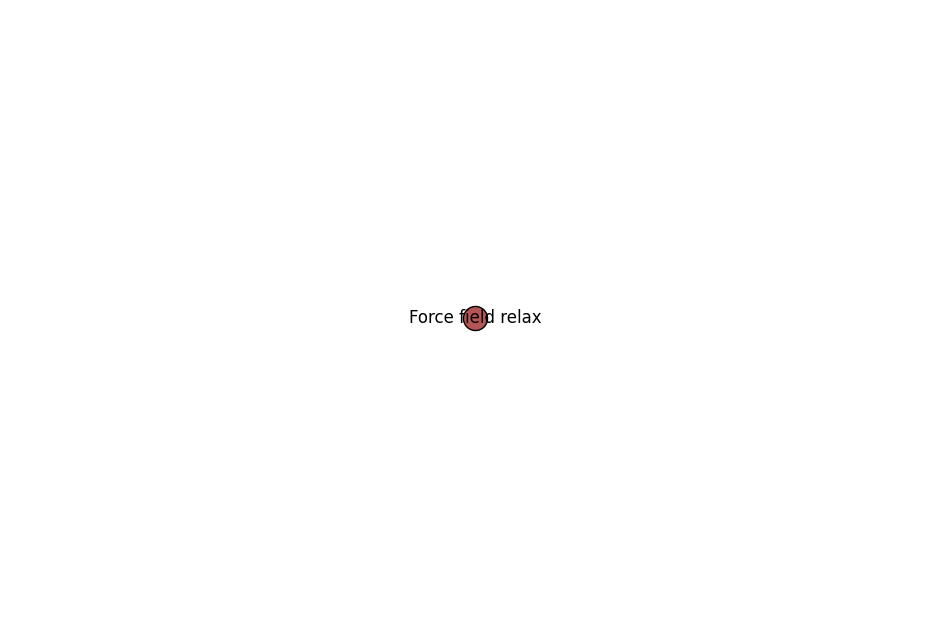

In [4]:
from atomate2.forcefields.jobs import ForceFieldRelaxMaker
from jobflow import Flow

# define the workflow to relax the structure
relax_job = ForceFieldRelaxMaker(force_field_name="MATPES_PBE").make(si_structure)
relax_flow = Flow(relax_job)  # a one-job Workflow (you could also chain multiple jobs or complex graphs into a Workflow)

# visualize the workflow (only one job)
relax_flow.draw_graph().show()

Finally, let's run the workflow!

In [5]:
from jobflow import run_locally

# run the job
output = run_locally(relax_flow, create_folders=True)

2026-04-10 12:18:59,434 INFO Started executing jobs locally
2026-04-10 12:18:59,440 INFO Starting job - Force field relax (c167fee5-4ca9-4133-882e-12c098c9bc9a)
2026-04-10 12:19:03,639 INFO Finished job - Force field relax (c167fee5-4ca9-4133-882e-12c098c9bc9a)
2026-04-10 12:19:03,640 INFO Finished executing jobs locally


If everything is wired correctly, you should see output that looks like this:

```bash
2026-03-23 12:59:17,204 INFO Started executing jobs locally
2026-03-23 12:59:17,207 INFO Starting job - Force field relax (6e60598d-4424-4d54-b063-f8518109e5f7)
2026-03-23 12:59:28,860 INFO Finished job - Force field relax (6e60598d-4424-4d54-b063-f8518109e5f7)
2026-03-23 12:59:28,860 INFO Finished executing jobs locally
```

You should also see a new directory beginning with ``job_``. This directory likely contains a file named ``final_atoms_object.xyz``.  We can open up the xyz file to show that the lattice parameters have indeed been optimized down from 2.9 initially to ~2.75 and coordinates are closer to symmetry positions.

```
2
Lattice="0.03540659915704753 2.7559102187687237 2.755910214747353 2.7559102247238005 0.035406599953889964 2.7559102138497473 2.7559102343751185 2.755910227522436 0.03540659088164358" Properties=species:S:1:pos:R:3:forces:R:3 energy=-10.484356880187988 free_energy=-10.484356880187988 stress="0.0003380556299816817 0.0033009089529514313 0.0033009089529514313 0.0033009094186127186 0.0003380581038072705 0.0033009094186127186 0.0033009089529514313 0.003300907090306282 0.000338060810463503" pbc="T T T"
Si       0.06329866       0.06329866       0.06329865      -0.03807587      -0.03807597      -0.03807602
Si       1.43445265       1.43445265       1.43445264       0.03807586       0.03807597       0.03807602
```

3. However, the majority of the outputs are not in the job run directory but rather in a central database file. Let's confirm that there is indeed a lot more information being stored than what exists in the directory:

```bash
cat path/to/output/output.json 
cat path/to/output/blob_output.json 
```

Next, we will briefly examine some of the outputs and how to access the stored data. Later in the tutorial, we will show how this method allows you to do powerful queries against your database of results.


----
**Note:**

- If the output does not seem to be writing, make sure that you have (i) remembered to set the ``JOBFLOW_CONFIG_FILE`` environment variable and (ii) that the ``jobflow.yaml`` file points to the correct output file.

## 3. Examining the output file

There are a few ways to examine the outputs of your calculations. Two ways that we will cover in this tutorial are:

1. Visually using a JSON inspector tool
2. Programmatically by connecting to your ``Store`` object and using Mongo-like queries

Let's start by using a JSON inspector / JSON visualizer tool to take a look at the output

## 3.1 Using a JSON visualizer to visualize the output data.

You can download one of several JSON editor / visualization packages to inspect the data from the simulation. Here, I am using one called "Cocoa JSON Editor", however most of them are very similar.

Let's open the file with the visualizer. You will see something like this:

![Output visualization 1](graphics/viz1.png)

At this top-level view, we don't see much - mainly just when the job was completed. Things become more interesting when we expand one of the keys - e.g., if we expand the output key:

![Visualization 2](graphics/viz2.png)

Now we see much more information! Some of the things you could see in the above JSON file:
- name of the force field used to perform the calculation (``MLFF.MATPES_PBE``)
- ``dir_name`` - where the job was run
- the ``state`` of the calculation (it ran successfully)
- the ``formula_pretty`` of the material that was run (Si)
- and more

Note that we still see many keys that can be further expanded within the nested JSON document.

Let's expand one more level and look at the ``output`` sub-key of the ``output`` key (so this is ``output.output``). We can see even more information now, for example, we can see the total energy of the configuration and could expand out the final forces:

![Visualization 3](graphics/viz3.png)

Finally, note that more detailed and memory-intensive output data often exists in a separate location. In our configuration, we had set this to be a file called ``blob_output.json``. This output contains large, heavy-weight outputs. In later tutorials, we will show why this is helpful - a different kind of database can be used for these outputs.

For now, if we were to use our JSON visualizer to look at this file, we would see that it contains more information. In particular, it contains information on the forces / energies for each of the individual 22 ionic steps performed during this structure optimization. The data for the second (final) step matches the output data in ``output.json``.

![Visualization 4](graphics/viz4.png)

## 3.2 Using Python to access the output data

Although the visual view of the JSON file is helpful for exploring the data, programmatic access is required for most analyses. Python access allows you to:

- filter data to only the entries you care about (helpful when you have hundreds or thousands of calculations)
- retrieve the key/values that you care about
- retrieve data as pymatgen objects rather than primitives
- access the data even when it is stored in a different data format (e.g., in a MongoDB database instead of  JSON files)

This is therefore likely to be the most common way to access the data. Let's first write a script to connect to our output Store.

In [6]:
from jobflow import SETTINGS

# connect to the job store
store = SETTINGS.JOB_STORE
store.connect()

print(store.as_dict())

{'@module': 'jobflow.core.store', '@class': 'JobStore', '@version': '0.3.1', 'docs_store': {'@module': 'maggma.stores.mongolike', '@class': 'JSONStore', '@version': '0.72.1', 'paths': ['/Users/ajain/Documents/code_venvs/atomate2_env/output/output.json'], 'read_only': False, 'serialization_option': None, 'serialization_default': None, 'encoding': None}, 'additional_stores': {'data': {'@module': 'maggma.stores.mongolike', '@class': 'JSONStore', '@version': '0.72.1', 'paths': ['/Users/ajain/Documents/code_venvs/atomate2_env/output/blob_output.json'], 'read_only': False, 'serialization_option': None, 'serialization_default': None, 'encoding': None}}, 'save': {}, 'load': False}


Now that we are connected to the Store, we can do a query. Let's find all documents where the chemical formula is "Si" and retrieve the final optimized structure and energy from the simulation.

In [7]:
# query the job store
results = store.query(
    criteria={"output.formula_pretty": "Si"},
    properties=[
        "output.output.mol_or_struct",
        "output.output.energy_per_atom",
    ],
)

# take the first result only
result = list(results)[0]

# print the results
print("\n----\nReturned document\n----")
print(result)


----
Returned document
----
{'uuid': 'c167fee5-4ca9-4133-882e-12c098c9bc9a', 'index': 1, 'output': {'output': {'mol_or_struct': {'@module': 'pymatgen.core.structure', '@class': 'Structure', 'charge': 0.0, 'lattice': {'matrix': [[0.035406623105305395, 2.7559102317298985, 2.7559102207839925], [2.755910224863024, 0.03540663064143589, 2.755910212597494], [2.7559102464281233, 2.7559102451085007, 0.03540660962763679]], 'pbc': [True, True, True], 'a': 3.897606442335467, 'b': 3.897606431760024, 'c': 3.897606469805134, 'alpha': 59.14913580090096, 'beta': 59.14913591636322, 'gamma': 59.149135855674906, 'volume': 41.05580361760304}, 'properties': {}, 'sites': [{'species': [{'element': 'Si', 'occu': 1}], 'abc': [0.011410858988545075, 0.011410859481940835, 0.011410863462225205], 'properties': {}, 'label': 'Si', 'xyz': [0.06329863984040987, 0.06329863864741755, 0.06329862708337324]}, {'species': [{'element': 'Si', 'occu': 1}], 'abc': [0.25858914113461456, 0.2585891391041269, 0.25858913621350454], '

Let's access specific keys of the output. In particular, we will decode the Structure information back into a pymatgen Structure object using the monty library.

In [8]:
print("\n----\nEnergy per atom\n----")
print(result["output"]["output"]["energy_per_atom"])

# convert the structure to a pymatgen object
from monty.json import MontyDecoder
print("\n----\nFinal structure (as pymatgen object)\n----")
structure_dict = result["output"]["output"]["mol_or_struct"]
structure = MontyDecoder().process_decoded(structure_dict)

print(structure)
print(type(structure))


----
Energy per atom
----
-5.242178440093994

----
Final structure (as pymatgen object)
----
Full Formula (Si2)
Reduced Formula: Si
abc   :   3.897606   3.897606   3.897606
angles:  59.149136  59.149136  59.149136
pbc   :       True       True       True
Sites (2)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Si    0.011411  0.011411  0.011411
  1  Si    0.258589  0.258589  0.258589
<class 'pymatgen.core.structure.Structure'>


## 3.3 Pydantic document models

You may be curious if the complex data structure for the output documents are explained / enforced anywhere. These document structures are defined according to **pydantic** schemas. Pydantic is a commonly used Python library to facilitate documentation, enforcement, and format interconversion of schemas.

1. The ``@module`` and ``@class`` attributes of the document tell you the schema being used:


![Visualization 5](graphics/viz5.png)

You can print out the schema using pydantic tools. The schema contains the document model as well as a description of each field. The output is fairly verbose due to its completeness and is sometimes easier for a computer to read (e.g., an LLM or another computer program) than a human.

In [9]:
import json

from atomate2.forcefields.schemas import ForceFieldTaskDocument

schema = ForceFieldTaskDocument.model_json_schema()
print(json.dumps(schema, indent=2))

{
  "$defs": {
    "Element": {
      "description": "Enum representing an element in the periodic table.",
      "enum": [
        "H",
        "D",
        "T",
        "He",
        "Li",
        "Be",
        "B",
        "C",
        "N",
        "O",
        "F",
        "Ne",
        "Na",
        "Mg",
        "Al",
        "Si",
        "P",
        "S",
        "Cl",
        "Ar",
        "K",
        "Ca",
        "Sc",
        "Ti",
        "V",
        "Cr",
        "Mn",
        "Fe",
        "Co",
        "Ni",
        "Cu",
        "Zn",
        "Ga",
        "Ge",
        "As",
        "Se",
        "Br",
        "Kr",
        "Rb",
        "Sr",
        "Y",
        "Zr",
        "Nb",
        "Mo",
        "Tc",
        "Ru",
        "Rh",
        "Pd",
        "Ag",
        "Cd",
        "In",
        "Sn",
        "Sb",
        "Te",
        "I",
        "Xe",
        "Cs",
        "Ba",
        "La",
        "Ce",
        "Pr",
        "Nd",
        "Pm",
        

# 4. Running a more complex workflow - elastic tensor

The previous workflow was very simple - a single-step structure relaxation.

Atomate2 supports much more complex workflows that involve many individual ``Jobs``. For example, calculating an elastic tensor involves 11 jobs for a cubic material!

### Cubic material elastic constant steps

1. **Force field relax**
2. generate_elastic_deformations
3. run_elastic_deformations
4. **Force field relax deformation 1/6**
5. **Force field relax deformation 2/6**
6. **Force field relax deformation 3/6**
7. **Force field relax deformation 4/6**
8. **Force field relax deformation 5/6**
9. **Force field relax deformation 6/6**
10. store_inputs
11. fit_elastic_tensor

Only the force field relax jobs are performing simulations (7 of 11 jobs - these are bolded). The remaining 4 jobs are Python scripts that either generate crystal structures to run or analyze results.

Note that if you have parallel computing set up (not the case in this tutorial), then jobs 4-9 can be performed in parallel with atomate2 if you have multiple computing nodes available. Here, we will stick to running the jobs serially.

## 4.1 Create and run the job

Let's write a script to run an elastic tensor, then examine how this more complex workflow looks in the output database. We'll switch our material from Si to GaAs also.

In [10]:
from pymatgen.core import Structure

# construct a zinc blende GaAs structure
gaas_structure = Structure(
    lattice=[[0, 2.8265, 2.8265], [2.8265, 0, 2.8265], [2.8265, 2.8265, 0]],
    species=["Ga", "As"],
    coords=[[0, 0, 0], [0.25, 0.25, 0.25]],
)

gaas_structure

Next, let's load the elastic tensor workflow. This is as simple as loading the correct "Maker" that makes the "Flow" we want from the atomate2 library.

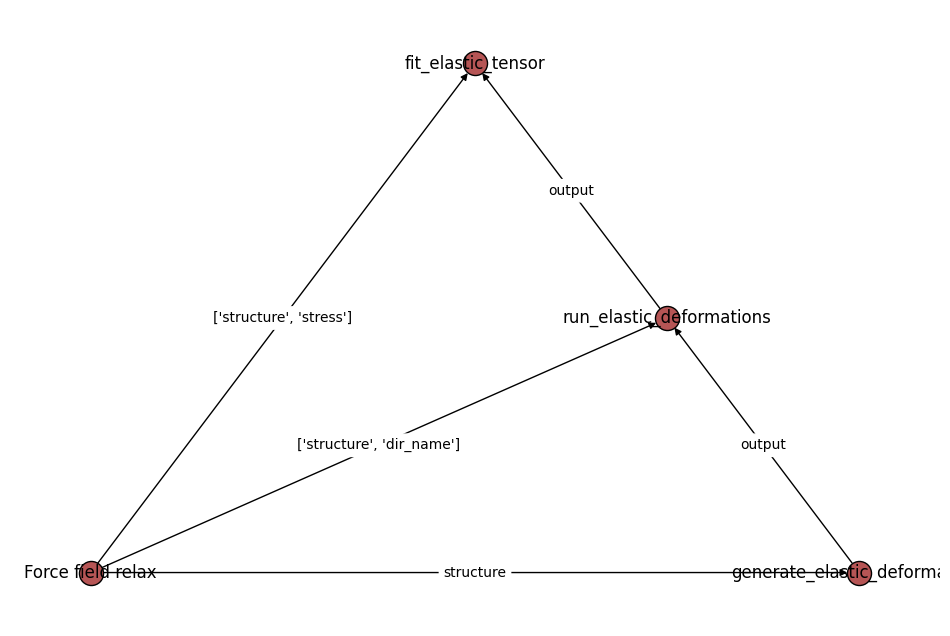

In [11]:
from atomate2.forcefields.flows.elastic import ElasticMaker
elastic_flow = ElasticMaker.from_force_field_name("MATPES_PBE").make(gaas_structure)

elastic_flow.draw_graph().show()

Now that we have a Flow, let's run this workflow locally using the same code as last time.

In [12]:
from jobflow import run_locally

# run the job
output = run_locally(elastic_flow, create_folders=True)

2026-04-10 12:34:44,907 INFO Started executing jobs locally
2026-04-10 12:34:44,910 INFO Starting job - Force field relax (24f16a40-cd90-40ce-a460-46f521cab191)
2026-04-10 12:34:47,127 INFO Finished job - Force field relax (24f16a40-cd90-40ce-a460-46f521cab191)
2026-04-10 12:34:47,129 INFO Starting job - generate_elastic_deformations (b189bb0a-d4ba-4c7c-8000-5e9db8d4bfbe)
2026-04-10 12:34:47,464 INFO Finished job - generate_elastic_deformations (b189bb0a-d4ba-4c7c-8000-5e9db8d4bfbe)
2026-04-10 12:34:47,465 INFO Starting job - run_elastic_deformations (fe0523a9-0898-41ac-a5f7-dee641db2d1e)
2026-04-10 12:34:47,511 INFO Finished job - run_elastic_deformations (fe0523a9-0898-41ac-a5f7-dee641db2d1e)
2026-04-10 12:34:47,517 INFO Starting job - Force field relax 1/6 (453a6d21-1730-4d0b-b960-fa7182227716)
2026-04-10 12:34:47,873 INFO Finished job - Force field relax 1/6 (453a6d21-1730-4d0b-b960-fa7182227716)
2026-04-10 12:34:47,874 INFO Starting job - Force field relax 2/6 (ef80c97c-4bcb-4890-

If everything is wired correctly, you should see output that looks like this (warnings suppressed for clarity):

```bash
2026-04-04 13:00:42,586 INFO Started executing jobs locally
2026-04-04 13:00:42,591 INFO Starting job - Force field relax (e21af0a4-ced6-4663-9298-552bee41dc53)
2026-04-04 13:00:47,146 INFO Finished job - Force field relax (e21af0a4-ced6-4663-9298-552bee41dc53)
2026-04-04 13:00:47,146 INFO Starting job - generate_elastic_deformations (da6ca5c3-1c5d-4291-a7f9-a3ef87822f3c)
2026-04-04 13:00:47,442 INFO Finished job - generate_elastic_deformations (da6ca5c3-1c5d-4291-a7f9-a3ef87822f3c)
2026-04-04 13:00:47,443 INFO Starting job - run_elastic_deformations (21744665-e6e0-4663-8a16-a4823742757e)
2026-04-04 13:00:47,480 INFO Finished job - run_elastic_deformations (21744665-e6e0-4663-8a16-a4823742757e)
2026-04-04 13:00:47,483 INFO Starting job - Force field relax 1/6 (bb57cca6-48e7-4961-a688-de09424ad80d)
2026-04-04 13:00:47,797 INFO Finished job - Force field relax 1/6 (bb57cca6-48e7-4961-a688-de09424ad80d)
2026-04-04 13:00:47,798 INFO Starting job - Force field relax 2/6 (68ee3753-6f5f-452b-8f11-843de10c6f69)
2026-04-04 13:00:48,118 INFO Finished job - Force field relax 2/6 (68ee3753-6f5f-452b-8f11-843de10c6f69)
2026-04-04 13:00:48,119 INFO Starting job - Force field relax 3/6 (e2133cad-925a-4584-b8c3-6e21788d0f6b)
2026-04-04 13:00:48,447 INFO Finished job - Force field relax 3/6 (e2133cad-925a-4584-b8c3-6e21788d0f6b)
2026-04-04 13:00:48,447 INFO Starting job - Force field relax 4/6 (1dbb4b29-4d32-4929-a9ca-6979d969f7ef)
2026-04-04 13:00:48,769 INFO Finished job - Force field relax 4/6 (1dbb4b29-4d32-4929-a9ca-6979d969f7ef)
2026-04-04 13:00:48,769 INFO Starting job - Force field relax 5/6 (823b8567-e507-4428-a20d-f3b89d55b629)
2026-04-04 13:00:50,170 INFO Finished job - Force field relax 5/6 (823b8567-e507-4428-a20d-f3b89d55b629)
2026-04-04 13:00:50,170 INFO Starting job - Force field relax 6/6 (1206bb0d-c5c6-4fdf-97b1-0a45e00f1f1e)
2026-04-04 13:00:51,265 INFO Finished job - Force field relax 6/6 (1206bb0d-c5c6-4fdf-97b1-0a45e00f1f1e)
2026-04-04 13:00:51,266 INFO Starting job - store_inputs (21744665-e6e0-4663-8a16-a4823742757e, 2)
2026-04-04 13:00:51,270 INFO Finished job - store_inputs (21744665-e6e0-4663-8a16-a4823742757e, 2)
2026-04-04 13:00:51,271 INFO Starting job - fit_elastic_tensor (f9f54642-f569-467e-aa4a-294c506272f8)
2026-04-04 13:00:51,677 INFO Finished job - fit_elastic_tensor (f9f54642-f569-467e-aa4a-294c506272f8)
2026-04-04 13:00:51,677 INFO Finished executing jobs locally
```

You should also see **many** new directories beginning with ``job_``. Some of these directories (the ones pertaining to force field relaxations) will contain a file named ``final_atoms_object.xyz``. However, the directories pertaining to jobs that performed Python processing only may be completely empty! Remember, the majority of the information is in the database!

## 4.2 Examining the database visually

Once again, we can examine the database visually using a JSON editor. We see many new jobs have been created; we now have a total of 12 jobs, 1 from our previous structure optimization and 11 additional jobs from our elastic tensor calculation.

The final job in ``output.json`` is the *fit_elastic_tensor* job and its output contains the final elastic tensor (in two formats) and derived properties like bulk and shear moduli:

![Visualization 6](graphics/viz6.png)

### 4.2.1 Comparing the output and blob_output

We can also examine compare the outputs of ``output.json`` and ``blob_output.json``. We see there are more entries in ``output.json``. This is because only the simulation jobs write data to ``blob_output.json``. The jobs responsible for generating deformed structures or fitting the elastic tensors do not write anything to blob storage.

Note that the ``uuid`` field in ``output.json`` corresponds to the ``job_uuid`` in ``blob_output.json``. You can use these fields to match the data entry between the two Stores.

![Visualization 7](graphics/viz7.png)


## 4.3 Querying the database programmatically

As we just saw, we are starting to have many jobs in our database - 11 documents in our output database, and 7 documents in our blob storage. Now, it is more important to be able to programmatically query the database for the data that we want.

Let's access just the final elastic tensor output data of our GaAs calculation only.


In [13]:
from jobflow import SETTINGS

# connect to the job store
store = SETTINGS.JOB_STORE
store.connect()

In [14]:
# query the job store
# restrict to DB entries on GaAs and only the final job that reports the elastic tensor
# for matching entries, return the elastic tensor and derived properties like bulk moduli
results = store.query(
    criteria={"output.formula_pretty": "GaAs", "name": "fit_elastic_tensor"},
    properties=[
        "output.derived_properties",
        "output.elastic_tensor",
        "output.formula_pretty"
    ],
)

# take the first result only
result = list(results)[0]

# print the results
print("\n----\nReturned document\n----")
print(result)

# print the bulk modulus (Voigt-Reuss-Hill average)
print("\n----\nBulk modulus\n----")
print(result["output"]["derived_properties"]["k_vrh"])


----
Returned document
----
{'uuid': 'f499436b-e04c-417f-8aff-43943264957c', 'index': 1, 'output': {'formula_pretty': 'GaAs', 'elastic_tensor': {'raw': [[86.39567651938027, 36.789506533410226, 36.789506533410226, -8.67361737988407e-18, 5.273559366969493e-16, 5.551115123125784e-17], [36.789506533410226, 86.39567651938027, 36.78950653341023, 3.6082248300317573e-16, -8.673617379884045e-18, 3.4588127687366627e-15], [36.789506533410226, 36.78950653341023, 86.39567651938029, 3.33066907387547e-16, -1.9428902930940252e-16, -8.673617379884076e-18], [-8.67361737988407e-18, 3.6082248300317573e-16, 3.33066907387547e-16, 45.77851875213553, 1.2332544300874654e-33, 1.635167544040277e-33], [5.273559366969493e-16, -8.673617379884045e-18, -1.9428902930940252e-16, 1.2332544300874654e-33, 45.77851875213553, -1.270609138796384e-15], [5.551115123125784e-17, 3.4588127687366627e-15, -8.673617379884076e-18, 1.635167544040277e-33, -1.270609138796384e-15, 45.77852246326271]], 'ieee_format': [[86.39567651938025,

Let's write a quick script to make the elastic tensor visual. Since we have a cubic crystal, we expect 3 independent terms:
- stiffness along normal (same for x, y, and z)
- stiffness coupling between directions
- shear stiffness

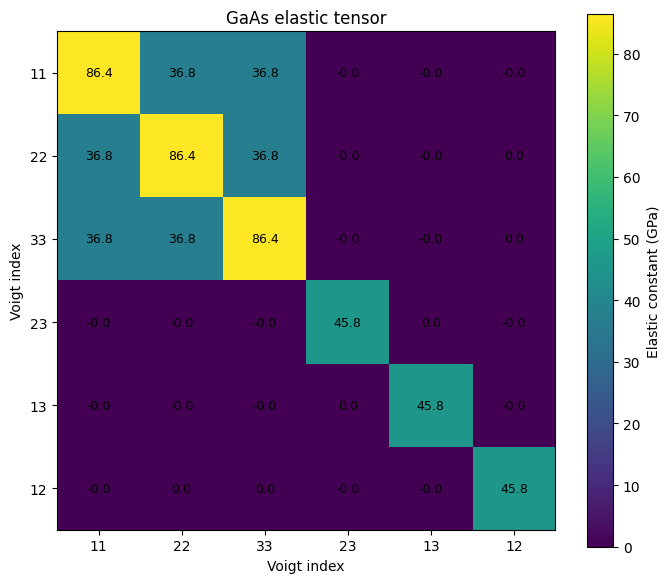

In [15]:
from jobflow import SETTINGS
import numpy as np
import matplotlib.pyplot as plt

formula = result["output"]["formula_pretty"]
C = np.array(result["output"]["elastic_tensor"]["ieee_format"], dtype=float)

# make a simple labeled heatmap
labels = ["11", "22", "33", "23", "13", "12"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(C)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Elastic constant (GPa)")

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title(f"{formula} elastic tensor")
ax.set_xlabel("Voigt index")
ax.set_ylabel("Voigt index")

# write values on the heatmap
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{C[i, j]:.1f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# 5. Final example - phonon dispersion of Si

We have now covered the fundamentals of running force field workflows locally and with a file-based database. Let's apply what we've done so far to running the phonon dispersion of Si.

As with our elastic tensor workflow, this will be a multi-step workflow in which many individual calculations / jobs are needed to perform the analysis.

## 5.1 Create and run the job

Let's write a script to run the phonon dispersion for Si. Mostly, we will just be switching the workflow in our workflow library.

In [16]:
from pymatgen.core import Structure

# construct an FCC silicon structure
si_structure = Structure(
    lattice=[[0, 2.73, 2.73], [2.73, 0, 2.73], [2.73, 2.73, 0]],
    species=["Si", "Si"],
    coords=[[0, 0, 0], [0.25, 0.25, 0.25]],
)

si_structure

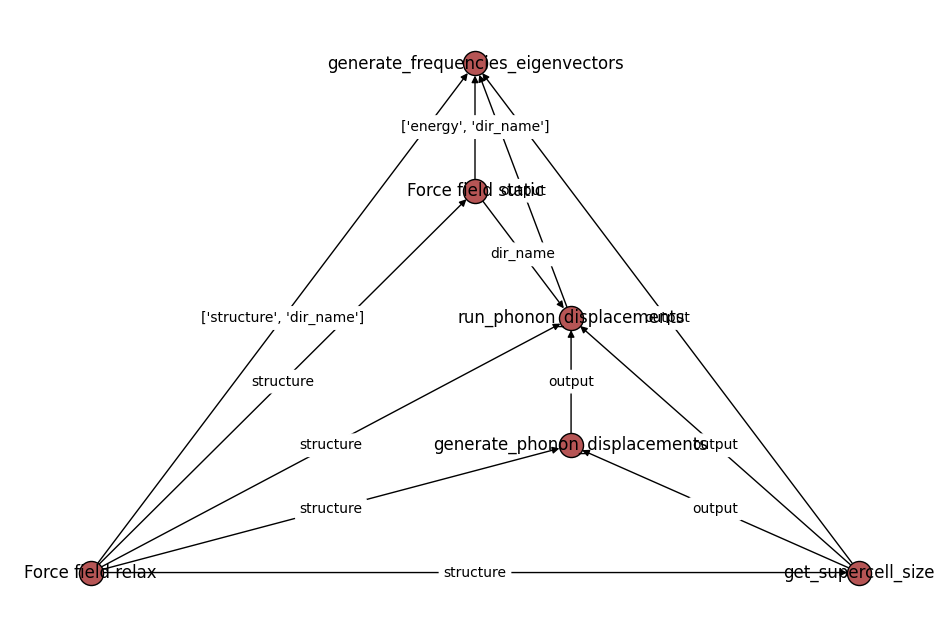

In [17]:
from atomate2.forcefields.flows.phonons import PhononMaker

phonon_flow = PhononMaker.from_force_field_name("MATPES_PBE").make(si_structure)
phonon_flow.draw_graph().show()

In [18]:
from jobflow import run_locally

# run the job
run_locally(phonon_flow, create_folders=True)

2026-04-10 12:45:24,337 INFO Started executing jobs locally
2026-04-10 12:45:24,340 INFO Starting job - Force field relax (0ad95c81-ee57-431f-b55a-1b06beaf6347)
2026-04-10 12:45:27,258 INFO Finished job - Force field relax (0ad95c81-ee57-431f-b55a-1b06beaf6347)
2026-04-10 12:45:27,260 INFO Starting job - get_supercell_size (3e78d9a6-a104-4f28-9b3a-fb9c3e3020b1)
2026-04-10 12:45:27,340 INFO Finished job - get_supercell_size (3e78d9a6-a104-4f28-9b3a-fb9c3e3020b1)
2026-04-10 12:45:27,343 INFO Starting job - Force field static (3f731f18-52f3-401f-875c-7e6b23014148)
2026-04-10 12:45:27,919 INFO Finished job - Force field static (3f731f18-52f3-401f-875c-7e6b23014148)
2026-04-10 12:45:27,921 INFO Starting job - generate_phonon_displacements (ed791e1a-01eb-4e59-be65-98a9c7e72d9e)
2026-04-10 12:45:32,054 INFO Finished job - generate_phonon_displacements (ed791e1a-01eb-4e59-be65-98a9c7e72d9e)
2026-04-10 12:45:32,055 INFO Starting job - run_phonon_displacements (a085e869-5790-4e4e-ae71-450e99acf6

{'0ad95c81-ee57-431f-b55a-1b06beaf6347': {1: Response(output=ForceFieldTaskDocument(forcefield_name='MLFF.MATPES_PBE', forcefield_version='2.1.1', dir_name='/Users/ajain/Documents/code_venvs/atomate2_env/notebook_pt1/job_2026-04-10-19-45-24-339851-88395', included_objects=[], objects={}, is_force_converged=True, nsites=2, elements=[Element Si], nelements=1, composition=Composition('Si2'), composition_reduced=Composition('Si1'), formula_pretty='Si', formula_anonymous='A', chemsys='Si', volume=41.03299626942356, density=2.273149623972503, density_atomic=20.51649813471178, symmetry=SymmetryData(crystal_system=<CrystalSystem.cubic: 'Cubic'>, symbol='Fd-3m', hall='F 4d 2 3 -1d', number=227, point_group='m-3m', symprec=0.1, angle_tolerance=5.0, version='2.7.0'), structure=Structure Summary
  Lattice
      abc : 3.8715310531947753 3.8715310208551257 3.871531030929538
   angles : 59.99999854030582 59.99999987255686 59.99999961894892
   volume : 41.03299626942356
        A : 8.675212715382872e-

If everything is wired correctly, you should see output that looks like this (warnings suppressed for clarity):

```bash
2026-04-04 13:27:06,257 INFO Started executing jobs locally
2026-04-04 13:27:06,260 INFO Starting job - Force field relax (ece0d03e-6cf6-4081-8bbf-1da49d9a2c98)
2026-04-04 13:27:10,949 INFO Finished job - Force field relax (ece0d03e-6cf6-4081-8bbf-1da49d9a2c98)
2026-04-04 13:27:10,949 INFO Starting job - get_supercell_size (14bebc33-73a8-473f-8a7d-8493c96ca706)
2026-04-04 13:27:10,999 INFO Finished job - get_supercell_size (14bebc33-73a8-473f-8a7d-8493c96ca706)
2026-04-04 13:27:11,000 INFO Starting job - Force field static (6a1b6b23-7bfd-46e5-968f-628b552acf28)
2026-04-04 13:27:11,360 INFO Finished job - Force field static (6a1b6b23-7bfd-46e5-968f-628b552acf28)
2026-04-04 13:27:11,361 INFO Starting job - generate_phonon_displacements (a82a19b5-03fa-463f-9189-feac12485904)
2026-04-04 13:27:14,466 INFO Finished job - generate_phonon_displacements (a82a19b5-03fa-463f-9189-feac12485904)
2026-04-04 13:27:14,466 INFO Starting job - run_phonon_displacements (0844360f-5c53-4bd8-93e0-474746cf30bd)
2026-04-04 13:27:14,604 INFO Finished job - run_phonon_displacements (0844360f-5c53-4bd8-93e0-474746cf30bd)
2026-04-04 13:27:14,631 INFO Starting job - Force field static 1/1 (77baef6c-8824-4716-9314-c1b4ea04e328)
2026-04-04 13:27:18,963 INFO Finished job - Force field static 1/1 (77baef6c-8824-4716-9314-c1b4ea04e328)
2026-04-04 13:27:18,964 INFO Starting job - store_inputs (0844360f-5c53-4bd8-93e0-474746cf30bd, 2)
2026-04-04 13:27:18,988 INFO Finished job - store_inputs (0844360f-5c53-4bd8-93e0-474746cf30bd, 2)
2026-04-04 13:27:18,989 INFO Starting job - generate_frequencies_eigenvectors (17ceda48-89bb-43dd-a805-b31b59f61e3f)
2026-04-04 13:28:06,816 INFO Finished job - generate_frequencies_eigenvectors (17ceda48-89bb-43dd-a805-b31b59f61e3f)
2026-04-04 13:28:06,858 INFO Finished executing jobs locally
```

4. As before, most of the outputs are in the database. However, in this workflow a PDF of the phonon band structure and phonon DOS are also written inside some of the directories:

```bash
(atomate2) computron:test_scripts ajain$ ls job*/*
job_2026-04-04-19-57-38-552955-98687/final_atoms_object.xyz
job_2026-04-04-20-00-42-589419-80319/final_atoms_object.xyz
job_2026-04-04-20-00-47-483632-92795/final_atoms_object.xyz
job_2026-04-04-20-00-47-797975-90495/final_atoms_object.xyz
job_2026-04-04-20-00-48-118857-57417/final_atoms_object.xyz
job_2026-04-04-20-00-48-447433-38308/final_atoms_object.xyz
job_2026-04-04-20-00-48-769565-24125/final_atoms_object.xyz
job_2026-04-04-20-00-50-170710-39994/final_atoms_object.xyz
job_2026-04-04-20-27-06-259301-39316/final_atoms_object.xyz
job_2026-04-04-20-27-10-999953-14289/final_atoms_object.xyz
job_2026-04-04-20-27-14-631778-81304/final_atoms_object.xyz
job_2026-04-04-20-27-18-989059-27383/phonon_band_structure.pdf
job_2026-04-04-20-27-18-989059-27383/phonon_band_structure.yaml
job_2026-04-04-20-27-18-989059-27383/phonon_dos.pdf
job_2026-04-04-20-27-18-989059-27383/phonon_dos.yaml
job_2026-04-04-20-27-18-989059-27383/phonopy.yaml
```

If we open the PDF files, we see helpful visualizations of the data:

![Visualization 8](graphics/viz8.png)

## 4.2 Examining the database visually

Let's examine the database visually using a JSON editor. Again, we see many new jobs have been created.

The final job in ``output.json`` is the *generate_frequencies_eigenvectors* job and its output contains the final data such as free energies and heat capacities (and associated temperature data).

However, large data outputs such as the phonon band structure and phonon DOS are simply linked to their corresponding entries in blob storage and not stored explicitly. In fact, our blob storage has now ballooned to over 50MB due to these objects. Our normal output Store is still <0.5MB, so our blob storage is now >100X as large as our basic Store.

![Visualization 10](graphics/viz10.png)

## 4.3 Create a script to access the data

### 4.3.1 Accessing the output data

Let's also write a script to connect to your database, perform a query, and return and plot the heat capacity data for our Si calculation.

In [19]:
from jobflow import SETTINGS

# connect to the job store
store = SETTINGS.JOB_STORE
store.connect()

# query the job store
results = store.query(
    criteria={
        "name": "generate_frequencies_eigenvectors",
        "output.formula_pretty": "Si",
    },
    properties=[
        "output.formula_pretty",
        "output.structure",
        "output.temperatures",
        "output.heat_capacities",
    ],
)

# take the first result only
result = list(results)[0]

# print the results
print("\n----\nReturned document\n----")
print(result)



----
Returned document
----
{'uuid': '3b122d87-e452-4b08-bb2f-e1d621b79318', 'index': 1, 'output': {'formula_pretty': 'Si', 'structure': {'@module': 'pymatgen.core.structure', '@class': 'Structure', 'charge': 0.0, 'lattice': {'matrix': [[8.675212715382872e-10, 2.737585857822277, 2.737585864754367], [2.7375858568011338, 4.5581548151229824e-08, 2.7375858200403385], [2.7375858673908637, 2.737585823697979, 3.499180354054216e-08]], 'pbc': [True, True, True], 'a': 3.8715310531947753, 'b': 3.8715310208551257, 'c': 3.871531030929538, 'alpha': 59.99999854030582, 'beta': 59.99999987255686, 'gamma': 59.99999961894892, 'volume': 41.03299626942356}, 'properties': {}, 'sites': [{'species': [{'element': 'Si', 'occu': 1}], 'abc': [-6.3068934159809e-09, -6.3120292252621355e-09, 2.0751665435088487e-09], 'properties': {}, 'label': 'Si', 'xyz': [-1.159877533827223e-08, -1.1584715998771648e-08, -3.45453838962457e-08]}, {'species': [{'element': 'Si', 'occu': 1}], 'abc': [0.2500000063378893, 0.2500000064207

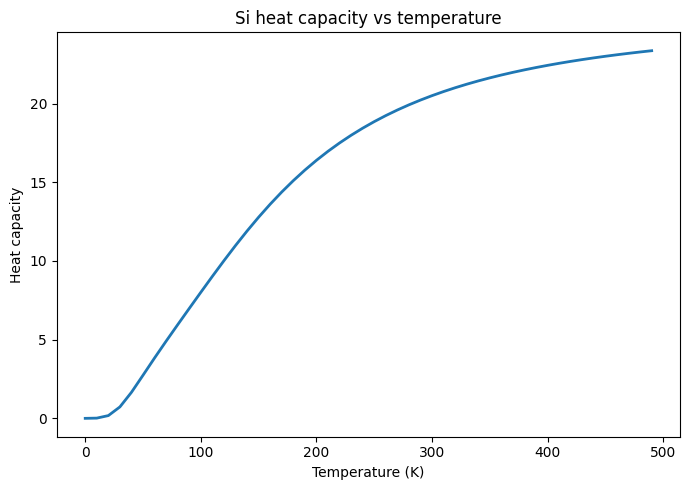

In [20]:
# extract full thermal data
temperatures = result["output"]["temperatures"]
heat_capacities = result["output"]["heat_capacities"]

# plot full temperature vs heat capacity
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(temperatures, heat_capacities, linewidth=2)
plt.xlabel("Temperature (K)")
plt.ylabel("Heat capacity")
plt.title("Si heat capacity vs temperature")
plt.tight_layout()
plt.show()

### 4.3.2 Create a script to access the blob data

Our final example will be the most complex. We will:
- query for the same phonon band structure output document - the one for Si
- retrieve the full phonon band structure from our blob storage
- convert that phonon band structure to a pymatgen object (``pymatgen.phonon.bandstructure.PhononBandStructureSymmLine``)
- print out some basic information about this object
- use pymatgen's built-in plotting capabilities to print out this object.


Let's begin by retrieving the full phonon band structure from blob storage.

In [21]:
from jobflow import SETTINGS

# connect to the stores
store = SETTINGS.JOB_STORE
store.connect()

blob_store = store.additional_stores["data"]
blob_store.connect()


# 1. get the Si phonon document
result = list(
    store.query(
        criteria={
            "name": "generate_frequencies_eigenvectors",
            "output.formula_pretty": "Si",
        },
        properties=["output.phonon_bandstructure"],
    )
)[0]

# 2. get the blob UUID for the phonon band structure object
blob_uuid = result["output"]["phonon_bandstructure"]["blob_uuid"]

# 3. load the serialized object from the blob store
blob_doc = list(
    blob_store.query(
        criteria={"blob_uuid": blob_uuid},
        properties=["data"],
    )
)[0]

# 4. decode into a pymatgen object
from monty.json import MontyDecoder
phonon_bandstructure = MontyDecoder().process_decoded(blob_doc["data"])

print(phonon_bandstructure)

PhononBandStructureSymmLine(bands=(6, 606), labels=['GAMMA', 'X', 'U', 'K', 'L', 'W'])


Let's summarize what this object contains and demonstrate basic analysis.

In [22]:
import numpy as np

# print the object itself
print("Pymatgen object:")
print(phonon_bandstructure)
print(type(phonon_bandstructure))

# basic summary
bands = phonon_bandstructure.bands
n_branches, n_qpoints = bands.shape

print("\nBasic summary")
print("-------------")
print("Number of phonon branches:", n_branches)
print("Number of q-points:", n_qpoints)
print("Minimum frequency (THz):", bands.min())
print("Maximum frequency (THz):", bands.max())
print("Has imaginary modes:", np.any(bands < 0))

# high-symmetry labels along the path
labels = [q.label for q in phonon_bandstructure.qpoints if q.label is not None]
print("\nHigh-symmetry labels along path:")
print(labels)

Pymatgen object:
PhononBandStructureSymmLine(bands=(6, 606), labels=['GAMMA', 'X', 'U', 'K', 'L', 'W'])
<class 'pymatgen.phonon.bandstructure.PhononBandStructureSymmLine'>

Basic summary
-------------
Number of phonon branches: 6
Number of q-points: 606
Minimum frequency (THz): -0.0047107904
Maximum frequency (THz): 14.0428300506
Has imaginary modes: True

High-symmetry labels along path:
['GAMMA', 'X', 'X', 'U', 'K', 'GAMMA', 'GAMMA', 'L', 'L', 'W', 'W', 'X']


Finally, let's use pymatgen's built-in tools to plot the band structure.

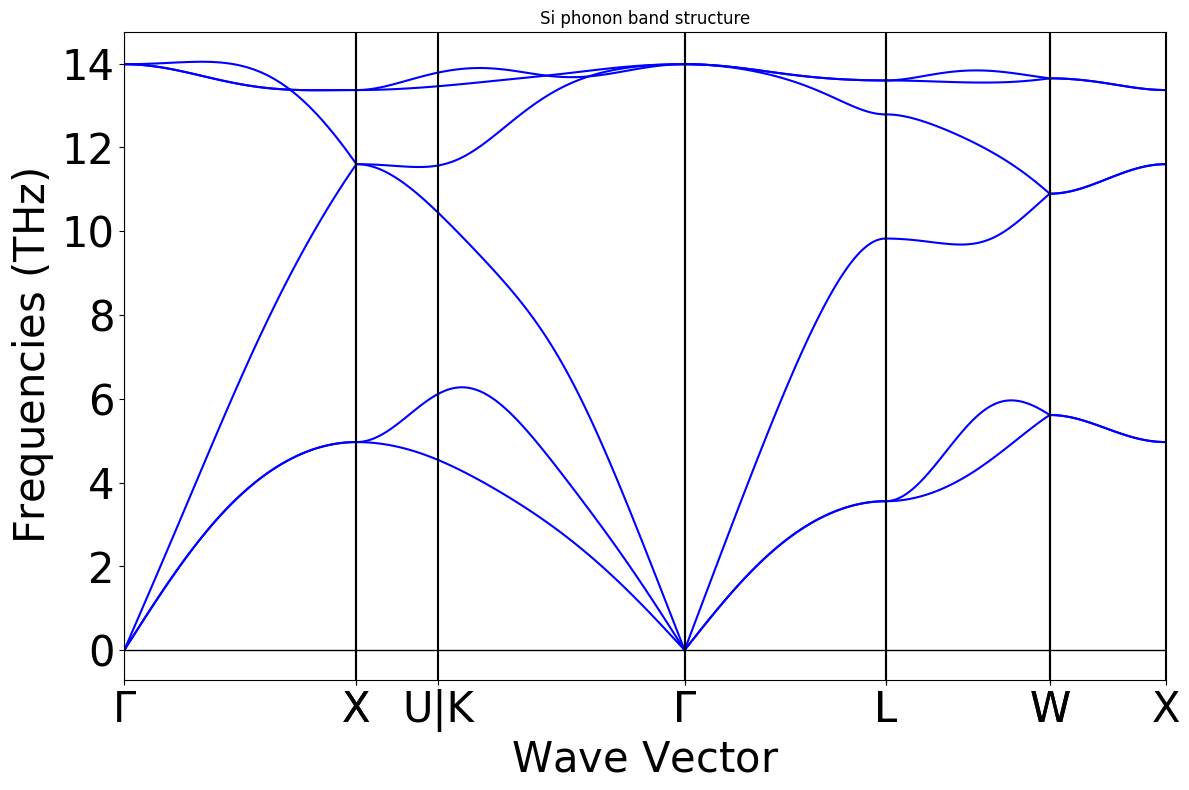

In [23]:
from pymatgen.phonon.plotter import PhononBSPlotter
import matplotlib.pyplot as plt

plotter = PhononBSPlotter(phonon_bandstructure)
plotter.get_plot()

plt.title("Si phonon band structure")
plt.tight_layout()
plt.show()

If everything worked correctly, you should see the following output and the plot below.

```
Pymatgen object:
PhononBandStructureSymmLine(bands=(6, 606), labels=['GAMMA', 'X', 'U', 'K', 'L', 'W'])
<class 'pymatgen.phonon.bandstructure.PhononBandStructureSymmLine'>

Basic summary
-------------
Number of phonon branches: 6
Number of q-points: 606
Minimum frequency (THz): 0.0037637186
Maximum frequency (THz): 14.0420751847
Has imaginary modes: False

High-symmetry labels along path:
['GAMMA', 'X', 'X', 'U', 'K', 'GAMMA', 'GAMMA', 'L', 'L', 'W', 'W', 'X']
```

![Visualization 13](graphics/viz13.png)

# 6. More resources and getting help

Congratulations, you now know the fundamentals of atomate2! However, it is important to realize that:
* this tutorial only covers a small fraction of what atomate2 does, in particular it does not cover the extensive library of density functional theory simulations available
* it also does not use best practices in terms of data storage and job execution

**Future tutorials will cover more powerful and recommended usage of atomate that allow you to perform more powerful simulations and scale to very large studies and databases.**


Other resources for atomate2 are listed below. Note that you can often also use LLMs / coding agents to help accomplish what you need!


### Video Tutorials

A full set of recorded tutorials from the atomate2 school (March 2025):

- [Jobflow and Jobflow-remote](https://lhumos.org/collection/0/680bb4d7e4b0f0d2028027ce)
- [atomate2 Overview](https://lhumos.org/collection/0/680bb4d3e4b0f0d2028027c9)
- [Advanced Workflows in atomate2 – Part 1](https://lhumos.org/collection/0/680bb4d0e4b0f0d2028027c5)
- [Advanced Workflows in atomate2 – Part 2](https://lhumos.org/collection/0/680bb4c7e4b0f0d2028027c1)


### Documentation

- [atomate2 documentation](https://materialsproject.github.io/atomate2/)


### Getting Help

- Ask questions on the community forum:  
  https://matsci.org/c/atomate

- Report bugs or request features:  
  https://github.com/materialsproject/atomate2/issues

